In [12]:
import torch

pt_file_path = "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data/db_AuSep_4_db_35_Rondeau_023.pt"
data = torch.load(pt_file_path, map_location="cpu")

print(f"データの型: {type(data)}")

if isinstance(data, dict):
    print(f"見つかったキー: {data.keys()}")
    # 例: dict_keys(['audio', 'sr', 'filename']) のように表示されます
else:
    print(f"Shape: {data.shape}")

データの型: <class 'dict'>
見つかったキー: dict_keys(['audio', 'mel', 'f0', 'loudness', 'instrument_name'])


In [15]:
import torch
import torchaudio
from IPython.display import Audio, display

# ==========================================
# 1. .pt ファイルの読み込み
# ==========================================
pt_file_path = "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data/sax_AuSep_2_sax_10_March_016.pt" # ★お手持ちの .pt ファイルのパス
# 辞書だった場合の処理]

loaded_data = torch.load(pt_file_path, map_location="cpu")

if isinstance(loaded_data, dict):
    # 'audio' や 'waveform' など、上記デバッグで確認したキーを指定してください
    # 一般的な名称で順に試行するコード例：
    waveform = loaded_data.get('audio', loaded_data.get('waveform', loaded_data.get('data', None)))

    if waveform is None:
        raise KeyError(f"波形データが見つかりません。キーを確認してください: {loaded_data.keys()}")
else:
    waveform = loaded_data

# テンソルの形状を (Channels, Time) に整える
# 例: [64000] や [1, 64000, 1] などを [1, 64000] の形にする
if waveform.ndim == 1:
    waveform = waveform.unsqueeze(0)
elif waveform.ndim == 3:
    waveform = waveform.squeeze(-1) # [Batch, Time, 1] などの場合

print(f"Loaded waveform shape: {waveform.shape}")

# サンプリングレートの設定（DDSPのデフォルトによく使われる16kHzを想定）
sample_rate = 16000

# ==========================================
# 2. Colab上で直接再生（可聴化）
# ==========================================
print("Listen to the audio:")
# IPythonのAudioウィジェットで再生インターフェースを表示
display(Audio(waveform.numpy()[0], rate=sample_rate))



Loaded waveform shape: torch.Size([1, 64000])
Listen to the audio:


Loading CLAP model...


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

Found 4 chunk files.


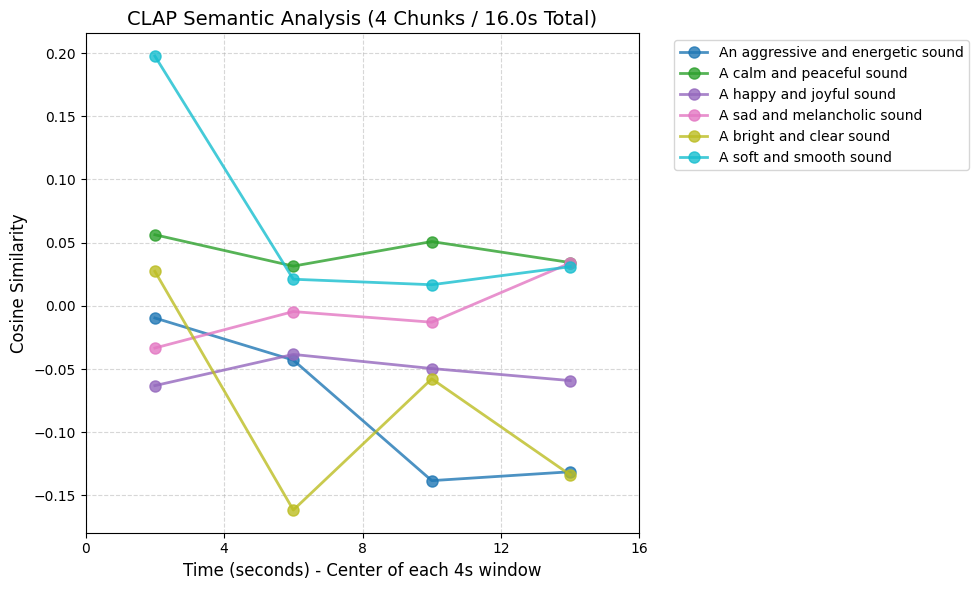

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import ClapModel, ClapProcessor
import glob
import matplotlib as mpl
import librosa
import os

# ==========================================
# 1. CLAPの準備
# ==========================================
print("Loading CLAP model...")
model_id = "laion/clap-htsat-unfused"
processor = ClapProcessor.from_pretrained(model_id)
model = ClapModel.from_pretrained(model_id)
model.eval()

text_prompts = [
    "An aggressive and energetic sound",
    "A calm and peaceful sound",
    "A happy and joyful sound",
    "A sad and melancholic sound",
    "A bright and clear sound",
    "A soft and smooth sound"
]

# ==========================================
# 2. .pt ファイルのリストアップと読み込み
# ==========================================
# # ★ .ptファイルが入っているフォルダのパスを指定してください
# pt_dir = "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data" # ★お手持ちの .pt ファイルのパス

# # フォルダ内の .pt ファイルを名前順（時系列順と仮定）に取得
# pt_files = sorted(glob.glob(os.path.join(pt_dir, "*.pt")))

pt_files = ["/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data/bn_AuSep_4_bn_28_Fugue_000.pt", "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data/db_AuSep_4_db_35_Rondeau_023.pt", "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data/fl_AuSep_1_fl_04_Allegro_018.pt", "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data/sax_AuSep_2_sax_10_March_016.pt"]
num_files = len(pt_files)
print(f"Found {len(pt_files)} chunk files.")

orig_sr = 16000 # PTファイルのサンプリングレート
target_sr = 48000
chunk_duration = 4.0
all_similarities = []

# ==========================================
# 3. 推論ループ
# ==========================================
for i, pt_file in enumerate(pt_files):
    loaded_data = torch.load(pt_file, map_location="cpu")

    if isinstance(loaded_data, dict):
        waveform = loaded_data.get('audio', loaded_data.get('waveform', loaded_data.get('data')))
        if waveform is None:
            for val in loaded_data.values():
                if isinstance(val, torch.Tensor):
                    waveform = val
                    break
    else:
        waveform = loaded_data

    if waveform is None: continue

    audio_np = waveform.squeeze().cpu().numpy()
    audio_resampled = librosa.resample(audio_np, orig_sr=orig_sr, target_sr=target_sr)

    inputs = processor(
        text=text_prompts,
        audio=audio_resampled,
        return_tensors="pt",
        padding=True,
        sampling_rate=target_sr
    )

    with torch.no_grad():
        outputs = model(**inputs)

    sim = F.cosine_similarity(outputs.audio_embeds, outputs.text_embeds, dim=-1).numpy()
    all_similarities.append(sim)

all_similarities = np.array(all_similarities)

# ==========================================
# 4. 可視化の改善 (Time軸の修正)
# ==========================================
# 各チャンクの中央（2s, 6s, 10s, 14s）にプロットすることで16秒の推移を表現
time_axis = np.arange(len(all_similarities)) * chunk_duration + (chunk_duration / 2)

plt.figure(figsize=(10, 6))

# Warningを回避する新しい色の取得方法
cmap = mpl.colormaps['tab10']
colors = cmap(np.linspace(0, 1, len(text_prompts)))

for j, prompt in enumerate(text_prompts):
    plt.plot(
        time_axis,
        all_similarities[:, j],
        label=prompt,
        color=colors[j],
        marker='o',      # 点を強調
        markersize=8,
        linewidth=2,
        alpha=0.8
    )

plt.title(f'CLAP Semantic Analysis ({num_files} Chunks / {num_files*chunk_duration}s Total)', fontsize=14)
plt.xlabel('Time (seconds) - Center of each 4s window', fontsize=12)
plt.ylabel('Cosine Similarity', fontsize=12)

# X軸の範囲をデータの終わり（例：16秒）まで明示的に広げる
plt.xlim(0, len(all_similarities) * chunk_duration)
plt.xticks(np.arange(0, (len(all_similarities) + 1) * chunk_duration, chunk_duration))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# データ保存
np.save('clap_similarities_4chunks.npy', all_similarities)